Research Plan:
What factors are most strongly associated with higher Medicare payments to physician and other practitioners in 2024?

Hypotheses
1. Providers performing more services will receive higher total Medicare payments.
2. Providers treating more beneficiaries will receive higher total payments.
3. Procedure heavy specialities will receive higher average payments than primary care specialities.
4. Some specialities will receive high payments because individual services are more expensive rather than because they perform more services.
5. Medicare payments will be concentrated among particular specialties. 



In [14]:
import pandas as pd
print ("Medicare analysis ready")

Medicare analysis ready


In [15]:
import requests
import pandas as pd

url ="https://data.cms.gov/data-api/v1/dataset/8889d81e-2ee7-448f-8713-f071038289b5/data"

In [16]:
response = requests.get(url)
print(response.status_code)

200


In [17]:
data = response.json()

In [18]:
type(data)

list

In [19]:
len(data)

1000

In [20]:
type(data[0])

dict

In [21]:
data[0].keys()

dict_keys(['Rndrng_NPI', 'Rndrng_Prvdr_Last_Org_Name', 'Rndrng_Prvdr_First_Name', 'Rndrng_Prvdr_MI', 'Rndrng_Prvdr_Crdntls', 'Rndrng_Prvdr_Ent_Cd', 'Rndrng_Prvdr_St1', 'Rndrng_Prvdr_St2', 'Rndrng_Prvdr_City', 'Rndrng_Prvdr_State_Abrvtn', 'Rndrng_Prvdr_State_FIPS', 'Rndrng_Prvdr_Zip5', 'Rndrng_Prvdr_RUCA', 'Rndrng_Prvdr_RUCA_Desc', 'Rndrng_Prvdr_Cntry', 'Rndrng_Prvdr_Type', 'Rndrng_Prvdr_Mdcr_Prtcptg_Ind', 'Tot_HCPCS_Cds', 'Tot_Benes', 'Tot_Srvcs', 'Tot_Sbmtd_Chrg', 'Tot_Mdcr_Alowd_Amt', 'Tot_Mdcr_Pymt_Amt', 'Tot_Mdcr_Stdzd_Amt', 'Drug_Sprsn_Ind', 'Drug_Tot_HCPCS_Cds', 'Drug_Tot_Benes', 'Drug_Tot_Srvcs', 'Drug_Sbmtd_Chrg', 'Drug_Mdcr_Alowd_Amt', 'Drug_Mdcr_Pymt_Amt', 'Drug_Mdcr_Stdzd_Amt', 'Med_Sprsn_Ind', 'Med_Tot_HCPCS_Cds', 'Med_Tot_Benes', 'Med_Tot_Srvcs', 'Med_Sbmtd_Chrg', 'Med_Mdcr_Alowd_Amt', 'Med_Mdcr_Pymt_Amt', 'Med_Mdcr_Stdzd_Amt', 'Bene_Avg_Age', 'Bene_Age_LT_65_Cnt', 'Bene_Age_65_74_Cnt', 'Bene_Age_75_84_Cnt', 'Bene_Age_GT_84_Cnt', 'Bene_Feml_Cnt', 'Bene_Male_Cnt', 'Bene_Rac

## Data Source 
**Dataset:** Medicare Physician & Other Practitioners - By Provider
**Data Year:** 2024
**Source:** Centers for Medicare & Medicaid Services (CMS) Open Data
**Dataset Size:** 1,296,739 rows and 81 columns
**Latest Data Available:** 2024
**Update Frequency:** Annually
**CMS Last Updated:** May 21, 2026
**Access Method:** CMS Open Data API (JSON)
**Date Accessed:** August 14, 2026

The data were retrieved prgrammatically using Python's `requests` library rather than downloaded as a local file. The API response was returned in JSON Format. 

## Key Variables for Analysis

The analysis will focus on variables related to provider specialty, beneficiary volume, service volume, submitted charges, allowed amounts, and Medicare payments.

Primary variables

- `Rndrng_NPI` - National Provider Identifier
- `Rndrng_Prvdr_Type` - Provider specialty/type
- `Rndrng_PrvDR_Type` - Provider state
- `Tot_HCPCS_Cds` - Total distincy HCPCS codes
- `Tot_Benes` - Total Medicare beneficiaries
- `Tot_Srvcs` - Total services
- `Tot_Sbmtd_Chrg` - Total submitted charges
- `Tot_Mdcr_Alowd_Amt` - Total Medicare allowed amount
- `Tot_Mdcr_Pymt_Amt` - Total Medicare payment amount
- `Tot_Mdcr_Stdzd_Amt` - Standardized Medicare Payment amount


In [22]:
test_url = f"{url}?size=5000&offset=0"
test_response = requests.get(test_url)
print(test_response.status_code)
test_data = test_response.json()
print(len(test_data))



200
5000


In [23]:
df_test = pd.DataFrame(test_data)
df_test.head()

,Rndrng_NPI,Rndrng_Prvdr_Last_Org_Name,Rndrng_Prvdr_First_Name,Rndrng_Prvdr_MI,Rndrng_Prvdr_Crdntls,Rndrng_Prvdr_Ent_Cd,Rndrng_Prvdr_St1,Rndrng_Prvdr_St2,Rndrng_Prvdr_City,Rndrng_Prvdr_State_Abrvtn,...,Bene_CC_PH_Diabetes_V2_Pct,Bene_CC_PH_HF_NonIHD_V2_Pct,Bene_CC_PH_Hyperlipidemia_V2_Pct,Bene_CC_PH_Hypertension_V2_Pct,Bene_CC_PH_IschemicHeart_V2_Pct,Bene_CC_PH_Osteoporosis_V2_Pct,Bene_CC_PH_Parkinson_V2_Pct,Bene_CC_PH_Arthritis_V2_Pct,Bene_CC_PH_Stroke_TIA_V2_Pct,Bene_Avg_Risk_Scre
0,1003000126,Enkeshafi,Ardalan,,M.D.,I,6410 Rockledge Dr Ste 304,,Bethesda,MD,...,48,48,75,75,51,18,4,63,21,2.566
1,1003000134,Cibull,Thomas,L,M.D.,I,2650 Ridge Ave,Evanston Hospital,Evanston,IL,...,23,14,75,64,26,15,2,47,6,1.1958
2,1003000142,Khalil,Rashid,,M.D.,I,4126 N Holland Sylvania Rd,Suite 220,Toledo,OH,...,45,27,75,75,36,17,,75,11,1.6931
3,1003000423,Velotta,Jennifer,A,M.D.,I,8300 Tyler Blvd Ste 300,,Mentor,OH,...,17,,73,71,17,25,,45,,0.7931
4,1003000480,Rothchild,Kevin,B,MD,I,12605 E 16th Ave,,Aurora,CO,...,25,13,56,55,26,,,54,,1.458


In [24]:
df_test.shape

(5000, 81)

In [25]:
df_test.columns

Index(['Rndrng_NPI', 'Rndrng_Prvdr_Last_Org_Name', 'Rndrng_Prvdr_First_Name',
       'Rndrng_Prvdr_MI', 'Rndrng_Prvdr_Crdntls', 'Rndrng_Prvdr_Ent_Cd',
       'Rndrng_Prvdr_St1', 'Rndrng_Prvdr_St2', 'Rndrng_Prvdr_City',
       'Rndrng_Prvdr_State_Abrvtn', 'Rndrng_Prvdr_State_FIPS',
       'Rndrng_Prvdr_Zip5', 'Rndrng_Prvdr_RUCA', 'Rndrng_Prvdr_RUCA_Desc',
       'Rndrng_Prvdr_Cntry', 'Rndrng_Prvdr_Type',
       'Rndrng_Prvdr_Mdcr_Prtcptg_Ind', 'Tot_HCPCS_Cds', 'Tot_Benes',
       'Tot_Srvcs', 'Tot_Sbmtd_Chrg', 'Tot_Mdcr_Alowd_Amt',
       'Tot_Mdcr_Pymt_Amt', 'Tot_Mdcr_Stdzd_Amt', 'Drug_Sprsn_Ind',
       'Drug_Tot_HCPCS_Cds', 'Drug_Tot_Benes', 'Drug_Tot_Srvcs',
       'Drug_Sbmtd_Chrg', 'Drug_Mdcr_Alowd_Amt', 'Drug_Mdcr_Pymt_Amt',
       'Drug_Mdcr_Stdzd_Amt', 'Med_Sprsn_Ind', 'Med_Tot_HCPCS_Cds',
       'Med_Tot_Benes', 'Med_Tot_Srvcs', 'Med_Sbmtd_Chrg',
       'Med_Mdcr_Alowd_Amt', 'Med_Mdcr_Pymt_Amt', 'Med_Mdcr_Stdzd_Amt',
       'Bene_Avg_Age', 'Bene_Age_LT_65_Cnt', 'Bene_Age_65_74

In [26]:
df_test.dtypes

Rndrng_NPI                        object
Rndrng_Prvdr_Last_Org_Name        object
Rndrng_Prvdr_First_Name           object
Rndrng_Prvdr_MI                   object
Rndrng_Prvdr_Crdntls              object
                                   ...  
Bene_CC_PH_Osteoporosis_V2_Pct    object
Bene_CC_PH_Parkinson_V2_Pct       object
Bene_CC_PH_Arthritis_V2_Pct       object
Bene_CC_PH_Stroke_TIA_V2_Pct      object
Bene_Avg_Risk_Scre                object
Length: 81, dtype: object

In [27]:
df_test.isnull().sum()

Rndrng_NPI                        0
Rndrng_Prvdr_Last_Org_Name        0
Rndrng_Prvdr_First_Name           0
Rndrng_Prvdr_MI                   0
Rndrng_Prvdr_Crdntls              0
                                 ..
Bene_CC_PH_Osteoporosis_V2_Pct    0
Bene_CC_PH_Parkinson_V2_Pct       0
Bene_CC_PH_Arthritis_V2_Pct       0
Bene_CC_PH_Stroke_TIA_V2_Pct      0
Bene_Avg_Risk_Scre                0
Length: 81, dtype: int64

In [28]:
df_test.duplicated().sum()

np.int64(0)

In [29]:
df_test.describe(include="all")

,Rndrng_NPI,Rndrng_Prvdr_Last_Org_Name,Rndrng_Prvdr_First_Name,Rndrng_Prvdr_MI,Rndrng_Prvdr_Crdntls,Rndrng_Prvdr_Ent_Cd,Rndrng_Prvdr_St1,Rndrng_Prvdr_St2,Rndrng_Prvdr_City,Rndrng_Prvdr_State_Abrvtn,...,Bene_CC_PH_Diabetes_V2_Pct,Bene_CC_PH_HF_NonIHD_V2_Pct,Bene_CC_PH_Hyperlipidemia_V2_Pct,Bene_CC_PH_Hypertension_V2_Pct,Bene_CC_PH_IschemicHeart_V2_Pct,Bene_CC_PH_Osteoporosis_V2_Pct,Bene_CC_PH_Parkinson_V2_Pct,Bene_CC_PH_Arthritis_V2_Pct,Bene_CC_PH_Stroke_TIA_V2_Pct,Bene_Avg_Risk_Scre
count,5000,5000,5000,5000,5000,5000,5000,5000,5000,5000,...,5000,5000,5000,5000,5000,5000,5000,5000,5000,5000
unique,5000,3988,2040,27,367,2,4279,647,1679,54,...,71,76,47,47,70,51,31,61,73,4440
top,1003317298,Patel,,,M.D.,I,200 1st St Sw,,New York,CA,...,,,75,75,,,,,,0.9867
freq,1,30,158,1970,1104,4842,25,4087,83,419,...,694,1183,3182,3109,829,1246,3090,416,1820,4


In [30]:
numeric_columns = ["Tot_HCPCS_Cds", 
                   "Tot_Benes",
                   "Tot_Srvcs",
                   "Tot_Sbmtd_Chrg",
                   "Tot_Mdcr_Alowd_Amt",
                   "Tot_Mdcr_Pymt_Amt",
                   "Tot_Mdcr_Stdzd_Amt"]

In [31]:
df_test[numeric_columns] = df_test[numeric_columns].apply(
    pd.to_numeric,
    errors="coerce"
)

In [32]:
df_test[numeric_columns].dtypes

Tot_HCPCS_Cds           int64
Tot_Benes               int64
Tot_Srvcs             float64
Tot_Sbmtd_Chrg        float64
Tot_Mdcr_Alowd_Amt    float64
Tot_Mdcr_Pymt_Amt     float64
Tot_Mdcr_Stdzd_Amt    float64
dtype: object

In [33]:
df_test[numeric_columns].isnull().sum()

Tot_HCPCS_Cds         0
Tot_Benes             0
Tot_Srvcs             0
Tot_Sbmtd_Chrg        0
Tot_Mdcr_Alowd_Amt    0
Tot_Mdcr_Pymt_Amt     0
Tot_Mdcr_Stdzd_Amt    0
dtype: int64

## Phase 4 - Data Dictionary

| Variable | Meaning | Type | Why It Matters |
|---|---|---|---|
|Rndrng_NPI | National Provider Identifier for the rendering provider | Text | Identifies each provider |
|Rndrng_Prvdr_Type | Provider specialty or practioner type | Text | Lets us compare payment patterns across specialities |
|Rndrng_Prvdr_State_Abrvtn | Provider state abbreviation | Text | Allows geographic comparisons |
|Tot_HCPCS_Cds| Total number of distinct HCPCS codes billed by the provider | Numeric | Measures the variety of services billed |
|Tot_Benes | Total Medicare beneficiaries associated with the provider | Numeric | Measures patient volume|
|Tot_Srvcs | Total services provided | Numeric | Measures service volume|
|Tot_Smtd_Chrg | Total charges submitted by the provider | Numeric | Shows what providers billed Medicare |
|Tot_Mdcr_Alowd_Amt | Total Medicare allowed amount | Numeric | Represents the amount Medicare recognized for covered services, including Medicare payment beneficiary cost sharing|
|Tot_Mdcr_Pymt_Amt | Total Medicare payment amount | Numeric | Represents the amount Medicare actually paid|
|Tot_Mdcr_Stdzd_Amt | Standardized Medicare payment amount | Numeric | Adjusts payments to make comparisons less affected by geographic payment differences|

In [34]:
df_test[
    [
        "Rndrng_NPI",
         "Rndrng_Prvdr_Type",
         "Rndrng_Prvdr_State_Abrvtn",
         "Tot_HCPCS_Cds",
         "Tot_Benes",
         "Tot_Srvcs",
         "Tot_Sbmtd_Chrg",
         "Tot_Mdcr_Alowd_Amt",
         "Tot_Mdcr_Pymt_Amt",
         "Tot_Mdcr_Stdzd_Amt"
    ]
].head()

,Rndrng_NPI,Rndrng_Prvdr_Type,Rndrng_Prvdr_State_Abrvtn,Tot_HCPCS_Cds,Tot_Benes,Tot_Srvcs,Tot_Sbmtd_Chrg,Tot_Mdcr_Alowd_Amt,Tot_Mdcr_Pymt_Amt,Tot_Mdcr_Stdzd_Amt
0,1003000126,Internal Medicine,MD,15,328,399.0,202783.88,46472.65,35325.46,34781.01
1,1003000134,Pathology,IL,21,912,2023.0,302581.00,69422.59,50178.11,47710.61
2,1003000142,Anesthesiology,OH,41,316,1369.0,381301.00,133096.84,101577.94,103554.75
3,1003000423,Obstetrics & Gynecology,OH,18,75,140.0,22015.00,8708.74,7134.32,7502.21
4,1003000480,General Surgery,CO,28,101,136.0,120420.00,24416.29,18766.80,18618.81


In [35]:
df_clean = df_test.copy()

In [36]:
text_columns = [
    "Rndrng_NPI",
    "Rndrng_Prvdr_Type",
    "Rndrng_Prvdr_State_Abrvtn"
]

for col in text_columns:
    print(col, (df_clean[col].str.strip()=="").sum())

Rndrng_NPI 0
Rndrng_Prvdr_Type 0
Rndrng_Prvdr_State_Abrvtn 0


In [37]:
for col in text_columns:
    df_clean[col] = df_clean[col].str.strip()

In [38]:
df_clean["Rndrng_Prvdr_State_Abrvtn"].value_counts().sort_index()

Rndrng_Prvdr_State_Abrvtn
AE      1
AK     10
AL     66
AP      1
AR     40
AZ     86
CA    419
CO    124
CT     58
DC     25
DE     21
FL    302
GA    135
HI     21
IA     54
ID     32
IL    191
IN     90
KS     46
KY     83
LA     74
MA    137
MD     94
ME     27
MI    159
MN    133
MO     87
MS     46
MT     16
NC    147
ND     17
NE     29
NH     27
NJ    149
NM     24
NV     32
NY    368
OH    204
OK     44
OR     76
PA    252
PR     13
RI     21
SC     68
SD     21
TN    119
TX    378
UT     27
VA    136
VT     14
WA    124
WI     92
WV     32
WY      8
Name: count, dtype: int64

In [39]:
df_clean[numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
Tot_HCPCS_Cds,5000.0,28.230200,2.923706e+01,1.00,9.0000,18.000,37.0000,2.580000e+02
Tot_Benes,5000.0,285.772200,5.156061e+02,11.00,63.0000,153.000,303.0000,1.013500e+04
Tot_Srvcs,5000.0,2067.834780,1.082327e+04,11.00,167.0000,451.000,1256.2500,4.196000e+05
Tot_Sbmtd_Chrg,5000.0,420352.115256,2.708156e+06,256.00,48059.0000,137413.000,341996.2500,1.737540e+08
Tot_Mdcr_Alowd_Amt,5000.0,142717.213354,2.228276e+06,80.35,14976.1550,40020.565,90741.6250,1.544715e+08
Tot_Mdcr_Pymt_Amt,5000.0,111655.730432,1.774733e+06,55.83,11236.5800,30645.920,70584.0725,1.230430e+08
Tot_Mdcr_Stdzd_Amt,5000.0,111193.706674,1.774163e+06,52.98,11227.1275,30629.400,69946.2800,1.229897e+08


In [40]:
for col in numeric_columns:
    print(col, (df_clean[col] < 0).sum())

Tot_HCPCS_Cds 0
Tot_Benes 0
Tot_Srvcs 0
Tot_Sbmtd_Chrg 0
Tot_Mdcr_Alowd_Amt 0
Tot_Mdcr_Pymt_Amt 0
Tot_Mdcr_Stdzd_Amt 0


In [41]:
df_clean["Payment_Per_Service"] = (
    df_clean["Tot_Mdcr_Pymt_Amt"]/ df_clean["Tot_Srvcs"]
)

In [42]:
df_clean["Payment_Per_Beneficiary"] = (
    df_clean["Tot_Mdcr_Pymt_Amt"] / df_clean["Tot_Benes"]
)

In [43]:
df_clean[
    ["Payment_Per_Service","Payment_Per_Beneficiary"]
].isnull().sum()

Payment_Per_Service        0
Payment_Per_Beneficiary    0
dtype: int64

In [44]:
df_clean[
    ["Payment_Per_Service", "Payment_Per_Beneficiary"]
].describe()

,Payment_Per_Service,Payment_Per_Beneficiary
count,5000.000000,5000.000000
mean,77.941928,385.383523
std,101.914280,2686.291934
min,0.986598,5.075455
25%,39.401433,114.087084
50%,66.482456,188.679054
75%,90.837015,329.443612
max,3178.930110,146654.357902


In [45]:
print("Rows:", df_clean.shape[0])
print("Columns:", df_clean.shape[1])

Rows: 5000
Columns: 83


In [46]:
unique_providers = df_clean["Rndrng_NPI"].nunique()
print("Unique Medicare Providers:", unique_providers)

Unique Medicare Providers: 5000


In [47]:
unique_specialties = df_clean["Rndrng_Prvdr_Type"].nunique()
print("Unique Provider Specialties:", unique_specialties)

Unique Provider Specialties: 87


In [48]:
df_clean.columns.tolist()

['Rndrng_NPI',
 'Rndrng_Prvdr_Last_Org_Name',
 'Rndrng_Prvdr_First_Name',
 'Rndrng_Prvdr_MI',
 'Rndrng_Prvdr_Crdntls',
 'Rndrng_Prvdr_Ent_Cd',
 'Rndrng_Prvdr_St1',
 'Rndrng_Prvdr_St2',
 'Rndrng_Prvdr_City',
 'Rndrng_Prvdr_State_Abrvtn',
 'Rndrng_Prvdr_State_FIPS',
 'Rndrng_Prvdr_Zip5',
 'Rndrng_Prvdr_RUCA',
 'Rndrng_Prvdr_RUCA_Desc',
 'Rndrng_Prvdr_Cntry',
 'Rndrng_Prvdr_Type',
 'Rndrng_Prvdr_Mdcr_Prtcptg_Ind',
 'Tot_HCPCS_Cds',
 'Tot_Benes',
 'Tot_Srvcs',
 'Tot_Sbmtd_Chrg',
 'Tot_Mdcr_Alowd_Amt',
 'Tot_Mdcr_Pymt_Amt',
 'Tot_Mdcr_Stdzd_Amt',
 'Drug_Sprsn_Ind',
 'Drug_Tot_HCPCS_Cds',
 'Drug_Tot_Benes',
 'Drug_Tot_Srvcs',
 'Drug_Sbmtd_Chrg',
 'Drug_Mdcr_Alowd_Amt',
 'Drug_Mdcr_Pymt_Amt',
 'Drug_Mdcr_Stdzd_Amt',
 'Med_Sprsn_Ind',
 'Med_Tot_HCPCS_Cds',
 'Med_Tot_Benes',
 'Med_Tot_Srvcs',
 'Med_Sbmtd_Chrg',
 'Med_Mdcr_Alowd_Amt',
 'Med_Mdcr_Pymt_Amt',
 'Med_Mdcr_Stdzd_Amt',
 'Bene_Avg_Age',
 'Bene_Age_LT_65_Cnt',
 'Bene_Age_65_74_Cnt',
 'Bene_Age_75_84_Cnt',
 'Bene_Age_GT_84_Cnt',
 'Bene_Fe

In [49]:
[col for col in df_clean.columns if "Bene" in col or "Srvcs" in col or "Pymt" in col]

['Tot_Benes',
 'Tot_Srvcs',
 'Tot_Mdcr_Pymt_Amt',
 'Drug_Tot_Benes',
 'Drug_Tot_Srvcs',
 'Drug_Mdcr_Pymt_Amt',
 'Med_Tot_Benes',
 'Med_Tot_Srvcs',
 'Med_Mdcr_Pymt_Amt',
 'Bene_Avg_Age',
 'Bene_Age_LT_65_Cnt',
 'Bene_Age_65_74_Cnt',
 'Bene_Age_75_84_Cnt',
 'Bene_Age_GT_84_Cnt',
 'Bene_Feml_Cnt',
 'Bene_Male_Cnt',
 'Bene_Race_Wht_Cnt',
 'Bene_Race_Black_Cnt',
 'Bene_Race_API_Cnt',
 'Bene_Race_Hspnc_Cnt',
 'Bene_Race_NatInd_Cnt',
 'Bene_Race_Othr_Cnt',
 'Bene_Dual_Cnt',
 'Bene_Ndual_Cnt',
 'Bene_CC_BH_ADHD_OthCD_V1_Pct',
 'Bene_CC_BH_Alcohol_Drug_V1_Pct',
 'Bene_CC_BH_Tobacco_V1_Pct',
 'Bene_CC_BH_Alz_NonAlzdem_V2_Pct',
 'Bene_CC_BH_Anxiety_V1_Pct',
 'Bene_CC_BH_Bipolar_V1_Pct',
 'Bene_CC_BH_Mood_V2_Pct',
 'Bene_CC_BH_Depress_V1_Pct',
 'Bene_CC_BH_PD_V1_Pct',
 'Bene_CC_BH_PTSD_V1_Pct',
 'Bene_CC_BH_Schizo_OthPsy_V1_Pct',
 'Bene_CC_PH_Asthma_V2_Pct',
 'Bene_CC_PH_Afib_V2_Pct',
 'Bene_CC_PH_Cancer6_V2_Pct',
 'Bene_CC_PH_CKD_V2_Pct',
 'Bene_CC_PH_COPD_V2_Pct',
 'Bene_CC_PH_Diabetes_V2_Pct',


In [50]:
total_beneficiaries = df_clean["Tot_Benes"].sum()
total_services = df_clean["Tot_Srvcs"].sum()
total_medicare_payments = df_clean["Tot_Mdcr_Pymt_Amt"].sum()

print("Total Beneficiaries:", total_beneficiaries)
print("Total Services:", total_services)
print("Total Medicare Payments: $", round(total_medicare_payments, 2))

Total Beneficiaries: 1428861
Total Services: 10339173.899999999
Total Medicare Payments: $ 558278652.16


In [58]:
avg_beneficiaries = df_clean["Tot_Benes"].mean()
median_beneficiaries = df_clean["Tot_Benes"].median()

avg_services = df_clean["Tot_Srvcs"].mean()
median_services = df_clean["Tot_Srvcs"].median()

avg_payment = df_clean["Tot_Mdcr_Pymt_Amt"].mean()
median_payment = df_clean["Tot_Mdcr_Pymt_Amt"].median()

print("Average Beneficiaries:", round(avg_beneficiaries, 2))
print("Median Beneficiaries:", round(median_beneficiaries, 2))

print("Average Services:", round(avg_services, 2))
print("Median Services:", round(median_services, 2))

print("Average Medicare Payment: $", round(avg_payment, 2))
print("Median Medicare Payment: $", round(median_payment, 2))


Average Beneficiaries: 285.77
Median Beneficiaries: 153.0
Average Services: 2067.83
Median Services: 451.0
Average Medicare Payment: $ 111655.73
Median Medicare Payment: $ 30645.92


In [55]:
df_clean["Payment_Per_Service"] = (
    df_clean["Tot_Mdcr_Pymt_Amt"] / df_clean["Tot_Srvcs"]
    )

In [56]:
df_clean [ 
    [
        "Rndrng_NPI",
        "Tot_Benes",
        "Tot_Srvcs",
        "Tot_Mdcr_Pymt_Amt",
        "Payment_Per_Beneficiary",
        "Payment_Per_Service"
    ]
].head()

,Rndrng_NPI,Tot_Benes,Tot_Srvcs,Tot_Mdcr_Pymt_Amt,Payment_Per_Beneficiary,Payment_Per_Service
0,1003000126,328,399.0,35325.46,107.699573,88.534987
1,1003000134,912,2023.0,50178.11,55.019857,24.803811
2,1003000142,316,1369.0,101577.94,321.449177,74.198641
3,1003000423,75,140.0,7134.32,95.124267,50.959429
4,1003000480,101,136.0,18766.80,185.809901,137.991176


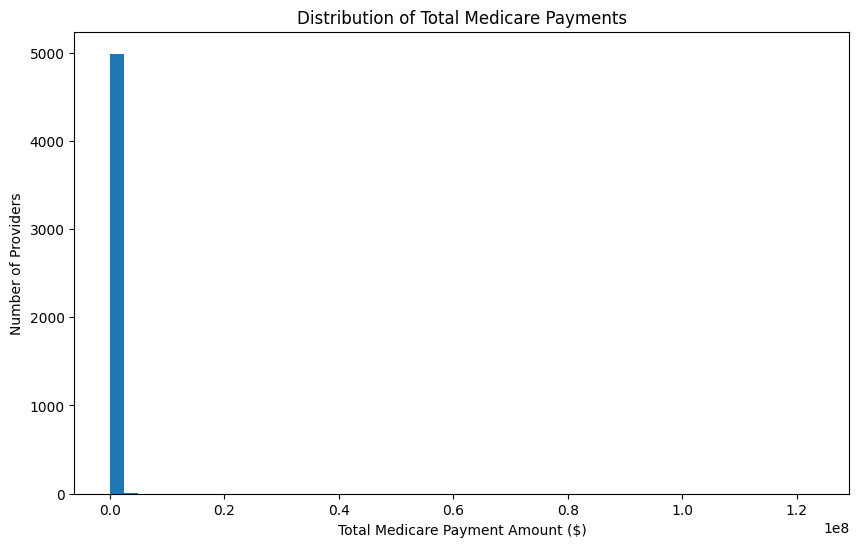

In [59]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.hist(
    df_clean["Tot_Mdcr_Pymt_Amt"],
    bins=50
)

plt.title("Distribution of Total Medicare Payments")
plt.xlabel("Total Medicare Payment Amount ($)")
plt.ylabel("Number of Providers")

plt.show()

In [60]:
df_clean["Tot_Mdcr_Pymt_Amt"].describe()


count    5.000000e+03
mean     1.116557e+05
std      1.774733e+06
min      5.583000e+01
25%      1.123658e+04
50%      3.064592e+04
75%      7.058407e+04
max      1.230430e+08
Name: Tot_Mdcr_Pymt_Amt, dtype: float64

In [61]:
df_clean["Tot_Mdcr_Pymt_Amt"].sort_values(ascending=False).head(10)

840     1.230430e+08
2117    1.593510e+07
2116    1.028788e+07
489     5.775238e+06
4140    4.935895e+06
2014    4.201488e+06
2814    4.059334e+06
1309    3.298769e+06
3967    2.977559e+06
1708    2.816859e+06
Name: Tot_Mdcr_Pymt_Amt, dtype: float64

In [62]:
df_clean.loc[
    840, 
    [
        "Rndrng_NPI",
        "Rndrng_Prvdr_Type",
        "Rndrng_Prvdr_State_Abrvtn",
        "Tot_Benes",
        "Tot_Srvcs",
        "Tot_Mdcr_Pymt_Amt",
        "Payment_Per_Beneficiary",
        "Payment_Per_Service"
    ]
]

Rndrng_NPI                          1003053851
Rndrng_Prvdr_Type            Internal Medicine
Rndrng_Prvdr_State_Abrvtn                   CA
Tot_Benes                                  839
Tot_Srvcs                             120972.0
Tot_Mdcr_Pymt_Amt                 123043006.28
Payment_Per_Beneficiary          146654.357902
Payment_Per_Service                1017.119716
Name: 840, dtype: object

In [65]:
payment_99th = df_clean["Tot_Mdcr_Pymt_Amt"].quantile(0.99)
print("99 Percentile Payment: $", round(payment_99th, 2))

99 Percentile Payment: $ 997573.34


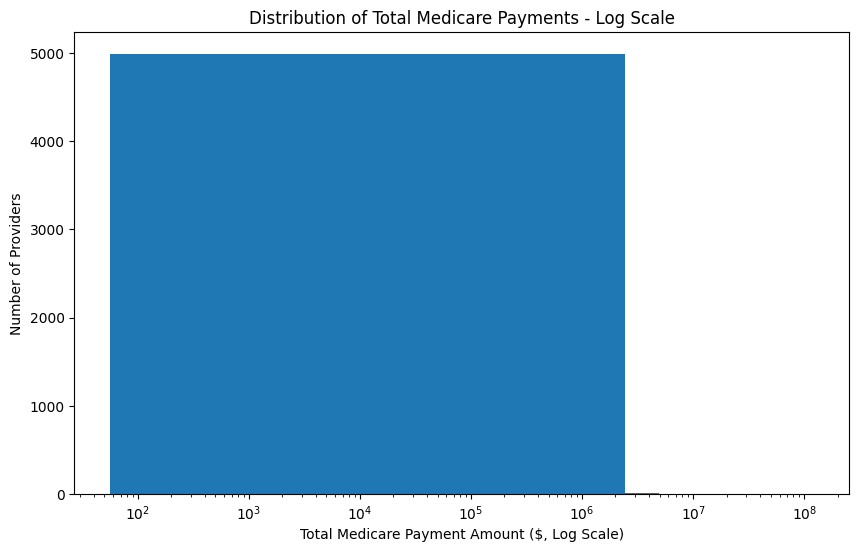

In [66]:
plt.figure(figsize=(10,6))

plt.hist(
    df_clean["Tot_Mdcr_Pymt_Amt"],
    bins=50
)

plt.xscale("log")

plt.title("Distribution of Total Medicare Payments - Log Scale")
plt.xlabel("Total Medicare Payment Amount ($, Log Scale)")
plt.ylabel("Number of Providers")

plt.show()


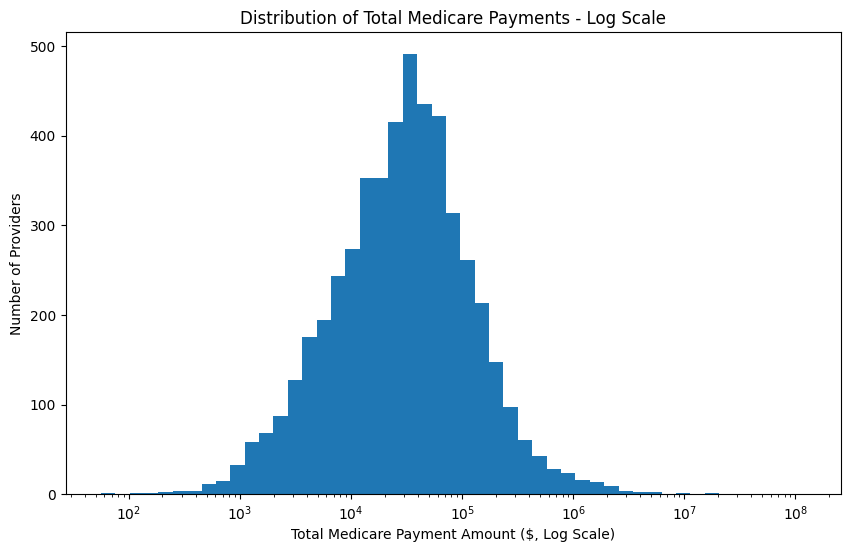

In [67]:
import numpy as np

payment_min = df_clean["Tot_Mdcr_Pymt_Amt"].min()
payment_max = df_clean["Tot_Mdcr_Pymt_Amt"].max()

log_bins = np.logspace(
    np.log10(payment_min),
    np.log10(payment_max),
    50
)

plt.figure(figsize=(10,6))

plt.hist(
    df_clean["Tot_Mdcr_Pymt_Amt"],
    bins=log_bins
)

plt.xscale("log")

plt.title("Distribution of Total Medicare Payments - Log Scale")
plt.xlabel("Total Medicare Payment Amount ($, Log Scale)")
plt.ylabel("Number of Providers")

plt.show()

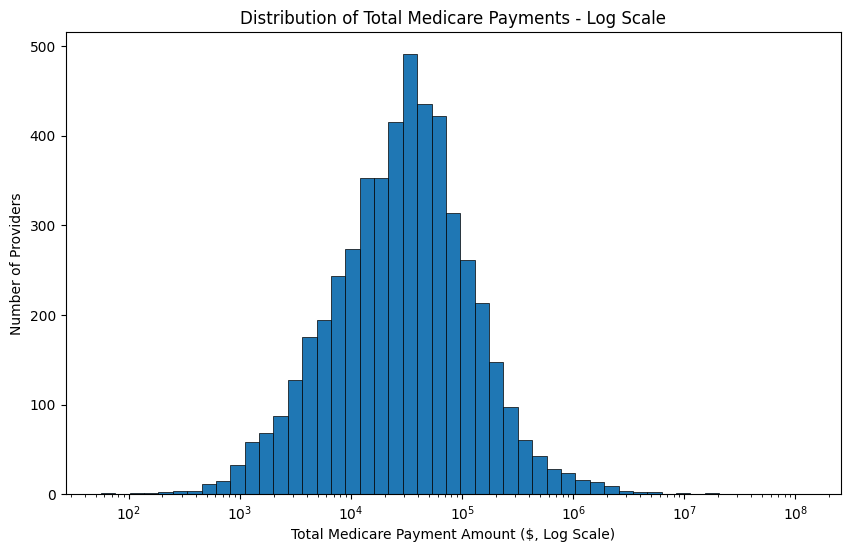

In [68]:
plt.figure(figsize=(10,6))

plt.hist(
    df_clean["Tot_Mdcr_Pymt_Amt"],
    bins=log_bins,
    edgecolor="black",
    linewidth=0.5
)

plt.xscale("log")

plt.title("Distribution of Total Medicare Payments - Log Scale")
plt.xlabel("Total Medicare Payment Amount ($, Log Scale)")
plt.ylabel("Number of Providers")

plt.show()

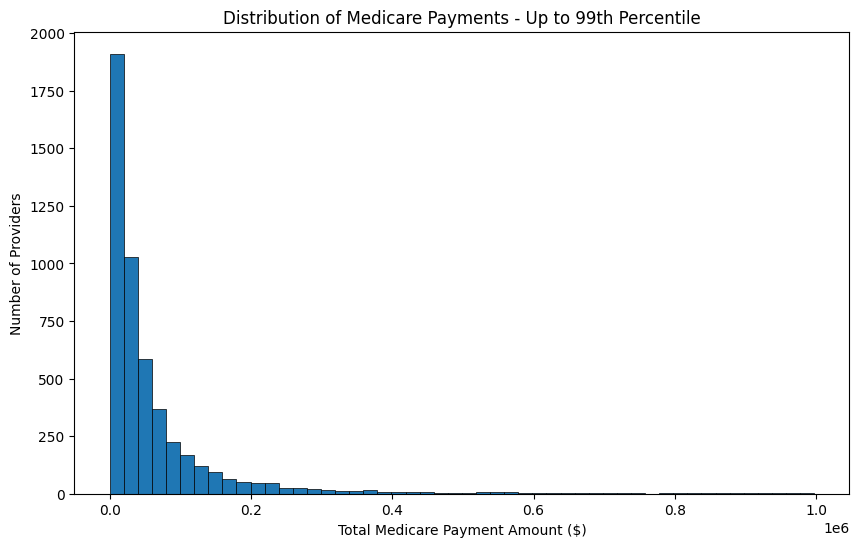

In [72]:
payments_below_99th = df_clean[
    df_clean["Tot_Mdcr_Pymt_Amt"] <= payment_99th
]

plt.figure(figsize=(10,6))

plt.hist(
    payments_below_99th["Tot_Mdcr_Pymt_Amt"],
    bins=50,
    edgecolor="black",
    linewidth=0.5
)

plt.title("Distribution of Medicare Payments - Up to 99th Percentile")
plt.xlabel("Total Medicare Payment Amount ($)")
plt.ylabel("Number of Providers")

plt.show()

In [73]:
specialty_payments = (
    df_clean.groupby("Rndrng_Prvdr_Type")["Tot_Mdcr_Pymt_Amt"]
    .median()
    .sort_values(ascending=False)
    .head(10)
)
specialty_payments

Rndrng_Prvdr_Type
Ambulatory Surgical Center                        764227.665
Micrographic Dermatologic Surgery                 431188.520
Portable X-Ray Supplier                           258304.380
Opioid Treatment Program                          238540.830
Clinical Cardiac Electrophysiology                220391.580
Ophthalmology                                     217982.010
Independent Diagnostic Testing Facility (IDTF)    215581.570
Nuclear Medicine                                  191670.270
Dermatology                                       184082.880
Ambulance Service Provider                        182597.090
Name: Tot_Mdcr_Pymt_Amt, dtype: float64

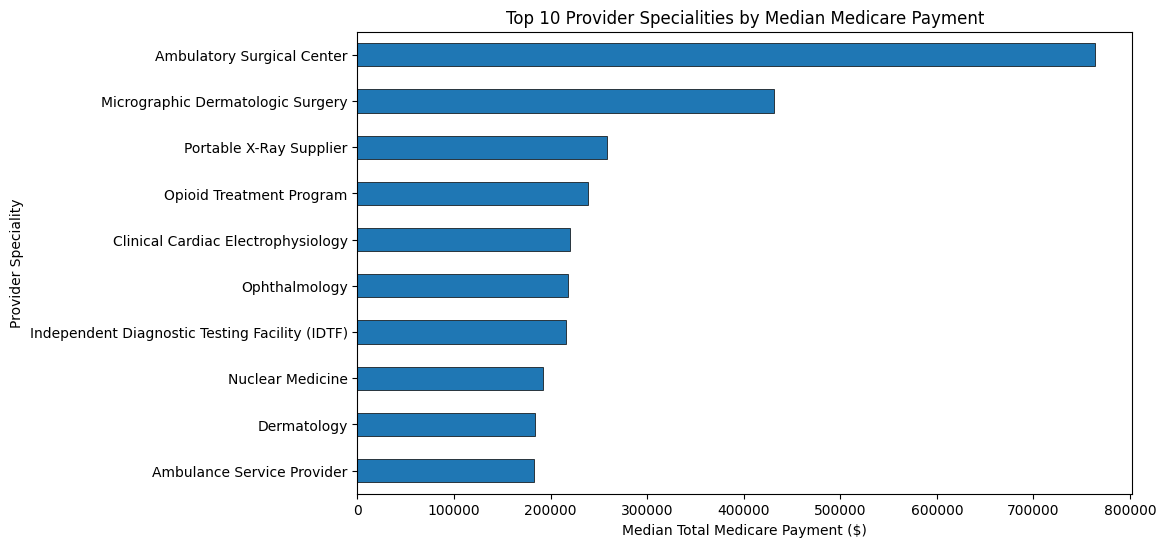

In [75]:
plt.figure(figsize=(10,6))

specialty_payments.sort_values().plot(
    kind="barh",
    edgecolor="black",
    linewidth=0.5
)

plt.title("Top 10 Provider Specialities by Median Medicare Payment")
plt.xlabel("Median Total Medicare Payment ($)")
plt.ylabel("Provider Speciality")

plt.show()

In [76]:
specialty_counts = (
    df_clean["Rndrng_Prvdr_Type"]
    .value_counts()
    .loc[specialty_payments.index]
)

specialty_counts

Rndrng_Prvdr_Type
Ambulatory Surgical Center                        20
Micrographic Dermatologic Surgery                  3
Portable X-Ray Supplier                            1
Opioid Treatment Program                           2
Clinical Cardiac Electrophysiology                 9
Ophthalmology                                     69
Independent Diagnostic Testing Facility (IDTF)     6
Nuclear Medicine                                   2
Dermatology                                       55
Ambulance Service Provider                        29
Name: count, dtype: int64

In [77]:
specialty_summary = pd.DataFrame({
    "Median_Medicare_Payment": specialty_payments,
    "Provider_Count": specialty_counts
})

specialty_summary

,Median_Medicare_Payment,Provider_Count
Rndrng_Prvdr_Type,,
Ambulatory Surgical Center,764227.665,20
Micrographic Dermatologic Surgery,431188.520,3
Portable X-Ray Supplier,258304.380,1
Opioid Treatment Program,238540.830,2
Clinical Cardiac Electrophysiology,220391.580,9
Ophthalmology,217982.010,69
Independent Diagnostic Testing Facility (IDTF),215581.570,6
Nuclear Medicine,191670.270,2
Dermatology,184082.880,55


In [78]:
specialty_stats = (
    df_clean.groupby("Rndrng_Prvdr_Type")
    .agg(
        Median_Medicare_Payment=("Tot_Mdcr_Pymt_Amt", "median"),
        Provider_Count=("Rndrng_NPI", "count")
    )
)

specialty_stats_filtered = (
    specialty_stats[specialty_stats["Provider_Count"]>= 10]
    .sort_values("Median_Medicare_Payment", ascending=False)
    .head(10)
)

specialty_stats_filtered

,Median_Medicare_Payment,Provider_Count
Rndrng_Prvdr_Type,,
Ambulatory Surgical Center,764227.665,20
Ophthalmology,217982.010,69
Dermatology,184082.880,55
Ambulance Service Provider,182597.090,29
Interventional Cardiology,148386.860,25
Physical Medicine and Rehabilitation,140531.590,38
Urology,138980.060,51
Nephrology,138348.295,42
Radiation Oncology,136105.890,29


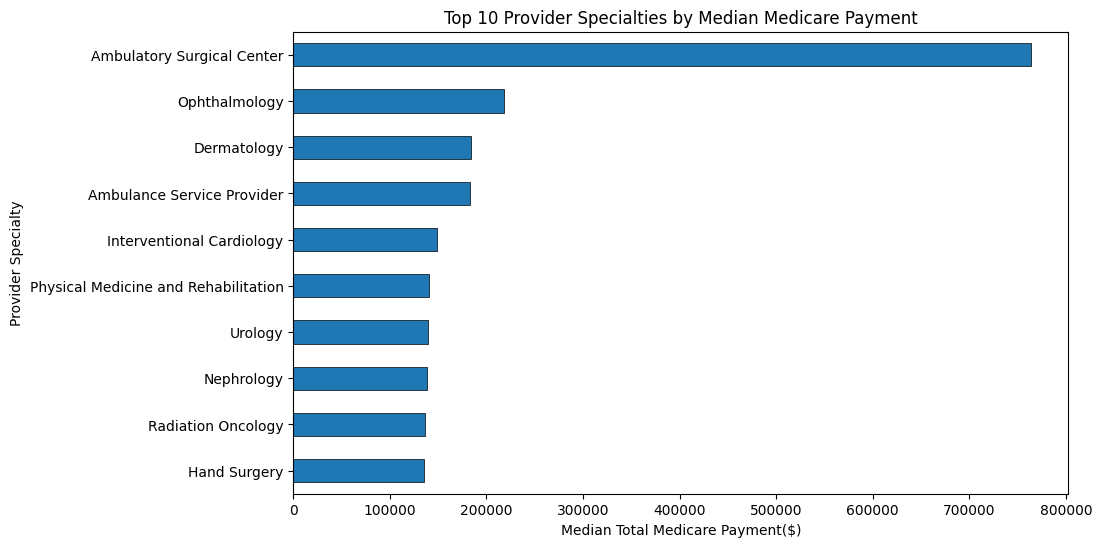

In [79]:
plt.figure(figsize=(10,6))

specialty_stats_filtered[
    "Median_Medicare_Payment"
].sort_values().plot(
    kind="barh",
    edgecolor="black",
    linewidth=0.5
)

plt.title("Top 10 Provider Specialties by Median Medicare Payment")
plt.xlabel("Median Total Medicare Payment($)")
plt.ylabel("Provider Specialty")

plt.show()

In [80]:
service_payment_corr = df_clean[
    ["Tot_Srvcs", "Tot_Mdcr_Pymt_Amt"]
].corr()

service_payment_corr

,Tot_Srvcs,Tot_Mdcr_Pymt_Amt
Tot_Srvcs,1.000000,0.255787
Tot_Mdcr_Pymt_Amt,0.255787,1.000000


In [81]:
corr_value = df_clean["Tot_Srvcs"].corr(
    df_clean["Tot_Mdcr_Pymt_Amt"]
)

print("Correlation between Services and Medicare Payments:", round(corr_value,3))

Correlation between Services and Medicare Payments: 0.256


In [82]:
spearman_corr = df_clean["Tot_Srvcs"].corr(
    df_clean["Tot_Mdcr_Pymt_Amt"],
    method="spearman"
)

print(
    "Spearman correlation between Services and Medicare Payments:", round(spearman_corr,3)
)

Spearman correlation between Services and Medicare Payments: 0.887


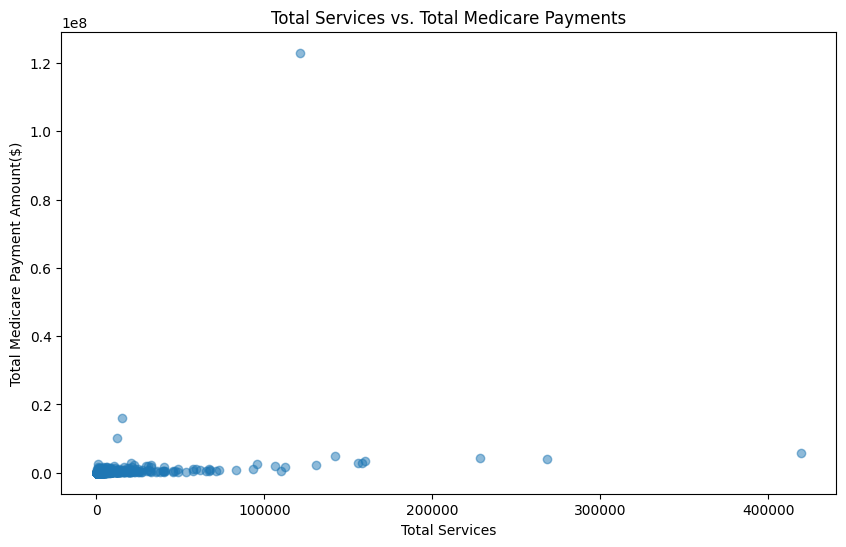

In [83]:
plt.figure(figsize=(10,6))

plt.scatter(
    df_clean["Tot_Srvcs"],
    df_clean["Tot_Mdcr_Pymt_Amt"],
    alpha=0.5
)

plt.title("Total Services vs. Total Medicare Payments")
plt.xlabel("Total Services")
plt.ylabel("Total Medicare Payment Amount($)")

plt.show()

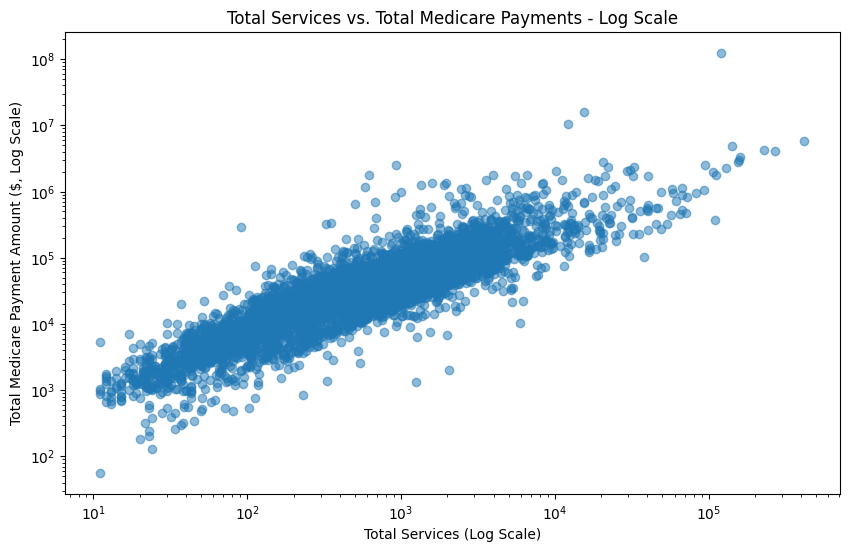

In [84]:
plt.figure(figsize=(10,6))

plt.scatter(
    df_clean["Tot_Srvcs"],
    df_clean["Tot_Mdcr_Pymt_Amt"],
    alpha=0.5
)

plt.xscale("log")
plt.yscale("log")

plt.title("Total Services vs. Total Medicare Payments - Log Scale")
plt.xlabel("Total Services (Log Scale)")
plt.ylabel("Total Medicare Payment Amount ($, Log Scale)")

plt.show()

In [86]:
bene_payment_corr = df_clean["Tot_Benes"].corr(
    df_clean["Tot_Mdcr_Pymt_Amt"],
    method="spearman"
)

print(
    "Spearman correlation between Beneficiaries and Medicare Payments",
    round(bene_payment_corr, 3)
)

Spearman correlation between Beneficiaries and Medicare Payments 0.813


In [87]:
bene_service_corr = df_clean["Tot_Benes"].corr(
    df_clean["Tot_Srvcs"],
    method="spearman"
)

print(
    "spearman correlation between Beneficiaries and Services:",
    round(bene_service_corr, 3)
)

spearman correlation between Beneficiaries and Services: 0.751


In [92]:
specialty_cost_intensity = (
    df_clean.groupby("Rndrng_Prvdr_Type")
    .agg(
        Median_Payment_Per_Beneficiary=("Payment_Per_Beneficiary", "median"),
        Median_Payment_Per_Service=("Payment_Per_Service", "median"),
        Provider_Count=("Rndrng_NPI", "count")
    )
)

specialty_cost_intensity_filtered = (
    specialty_cost_intensity[
        specialty_cost_intensity["Provider_Count"] >= 10
    ]
)

top_payment_per_bene = (
    specialty_cost_intensity_filtered
    .sort_values(
        "Median_Payment_Per_Beneficiary",
        ascending=False
    )
    .head(10)
)

top_payment_per_bene

,Median_Payment_Per_Beneficiary,Median_Payment_Per_Service,Provider_Count
Rndrng_Prvdr_Type,,,
Ambulatory Surgical Center,1511.544350,658.701911,20
Occupational Therapist in Private Practice,716.671228,21.271867,34
Radiation Oncology,703.009238,76.396647,29
Speech Language Pathologist,698.252500,58.825213,11
Ambulance Service Provider,670.530992,35.339699,29
Licensed Clinical Social Worker,639.557200,73.799194,59
Physical Therapist in Private Practice,547.566118,20.275866,223
Neurosurgery,546.605739,227.680654,37
"Psychologist, Clinical",517.278456,72.887137,41


In [98]:
top_payment_per_service = (
    specialty_cost_intensity_filtered
    .sort_values(
        "Median_Payment_Per_Service",
        ascending=False
    )
    .head(10)
)

top_payment_per_service

,Median_Payment_Per_Beneficiary,Median_Payment_Per_Service,Provider_Count
Rndrng_Prvdr_Type,,,
Ambulatory Surgical Center,1511.544350,658.701911,20
Neurosurgery,546.605739,227.680654,37
Surgical Oncology,442.725733,160.205681,10
General Surgery,330.827032,146.292590,97
Anesthesiology,161.910298,117.045090,197
Critical Care (Intensivists),275.170132,112.940211,33
Vascular Surgery,294.219167,110.508861,19
Certified Registered Nurse Anesthetist (CRNA),109.694155,102.060258,212
Gastroenterology,220.345605,96.417965,68


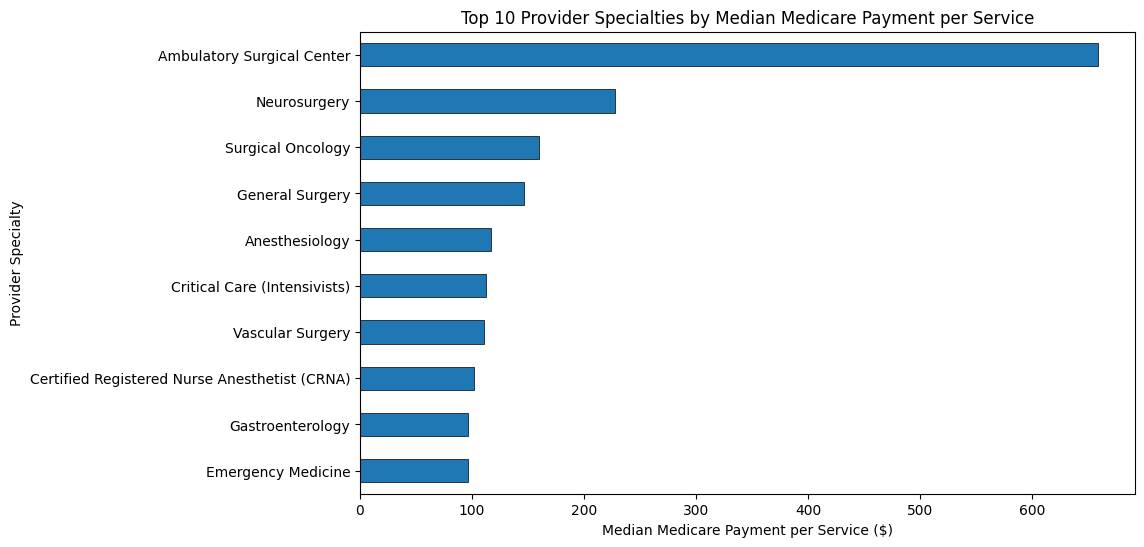

In [99]:
plt.figure(figsize=(10, 6))

top_payment_per_service[
    "Median_Payment_Per_Service"
].sort_values().plot(
    kind="barh",
    edgecolor="black",
    linewidth=0.5
)

plt.title("Top 10 Provider Specialties by Median Medicare Payment per Service")
plt.xlabel("Median Medicare Payment per Service ($)")
plt.ylabel("Provider Specialty")

plt.show()

In [100]:
phase6_summary = pd.DataFrame({
    "Metric": [
        "Average Beneficiaries",
        "Median Beneficiaries",
        "Average Services",
        "Median Services",
        "Average Medicare Payment",
        "Median Medicare Payment",
        "99th Percentile Medicare Payment",
        "Spearman: Services vs Payments",
        "Spearman: Beneficiaries vs Payments",
        "Spearman: Beneficiaries vs Services"
    ],
    "Value": [
        round(avg_beneficiaries, 2),
        round(median_beneficiaries, 2),
        round(avg_services, 2),
        round(median_services, 2),
        round(avg_payment, 2),
        round(median_payment, 2),
        round(payment_99th, 2),
        round(spearman_corr, 3),
        round(bene_payment_corr, 3),
        round(bene_service_corr, 3)
    ]
})

phase6_summary

,Metric,Value
0,Average Beneficiaries,285.770
1,Median Beneficiaries,153.000
2,Average Services,2067.830
3,Median Services,451.000
4,Average Medicare Payment,111655.730
5,Median Medicare Payment,30645.920
6,99th Percentile Medicare Payment,997573.340
7,Spearman: Services vs Payments,0.887
8,Spearman: Beneficiaries vs Payments,0.813
9,Spearman: Beneficiaries vs Services,0.751


In [101]:
phase6_specialty_summary = pd.DataFrame({
    "Finding": [
        "Highest Median Total Medicare Payment Specialty",
        "Highest Median Payment Per Service Specialty"
    ],
    "Specialty": [
        specialty_stats_filtered.index[0],
        top_payment_per_service.index[0]
    ],
    "Value": [
        round(
            specialty_stats_filtered.iloc[0]["Median_Medicare_Payment"],
            2
        ),
        round(
            top_payment_per_service.iloc[0]["Median_Payment_Per_Service"],
            2
        )
    ]
})

phase6_specialty_summary

,Finding,Specialty,Value
0,Highest Median Total Medicare Payment Specialty,Ambulatory Surgical Center,764227.66
1,Highest Median Payment Per Service Specialty,Ambulatory Surgical Center,658.70


In [102]:
phase7_evidence = pd.DataFrame({
    "Factor": [
        "Service Volume",
        "Beneficiary Volume",
        "Provider Specialty",
        "Payment Intensity"
    ],
    "Evidence": [
        "Spearman correlation with Medicare payments = 0.887",
        "Spearman correlation with Medicare payments = 0.813",
        "Large differences in median payments across specialties",
        "Large differences in median payment per service across specialties"
    ],
    "Interpretation": [
        "Very strong positive association",
        "Strong positive association",
        "Specialty appears associated with payment levels",
        "Some specialties receive substantially more per service"
    ]
})

phase7_evidence

,Factor,Evidence,Interpretation
0,Service Volume,Spearman correlation with Medicare payments = ...,Very strong positive association
1,Beneficiary Volume,Spearman correlation with Medicare payments = ...,Strong positive association
2,Provider Specialty,Large differences in median payments across sp...,Specialty appears associated with payment levels
3,Payment Intensity,Large differences in median payment per servic...,Some specialties receive substantially more pe...


In [103]:
phase7_conclusions = pd.DataFrame({
    "Research_Question": [
        "What factors are associated with higher Medicare payments?",
        "How important is provider volume?",
        "Does provider specialty matter?",
        "Are higher payments explained only by volume?"
    ],
    "Conclusion": [
        "Service volume, beneficiary volume, provider specialty, and payment intensity are all associated with Medicare payment levels.",
        "Provider volume is highly important. Service volume had a Spearman correlation of 0.887 with Medicare payments, while beneficiary volume had a correlation of 0.813.",
        "Yes. Median Medicare payments varied substantially across specialties, even after restricting comparisons to specialties with at least 10 providers.",
        "No. Differences in payment per service show that higher total payments reflect both the amount of care delivered and differences in payment intensity across specialties."
    ]
})

phase7_conclusions

,Research_Question,Conclusion
0,What factors are associated with higher Medica...,"Service volume, beneficiary volume, provider s..."
1,How important is provider volume?,Provider volume is highly important. Service v...
2,Does provider specialty matter?,Yes. Median Medicare payments varied substanti...
3,Are higher payments explained only by volume?,No. Differences in payment per service show th...


In [104]:
high_payment_providers = df_clean[
    df_clean["Tot_Mdcr_Pymt_Amt"] > payment_99th
].copy()

print(
    "Number of providers above the 99th percentile:",
    len(high_payment_providers)
)

Number of providers above the 99th percentile: 50


In [105]:
high_payment_providers[
    [
        "Rndrng_NPI",
        "Rndrng_Prvdr_Type",
        "Rndrng_Prvdr_State_Abrvtn",
        "Tot_Benes",
        "Tot_Srvcs",
        "Tot_Mdcr_Pymt_Amt",
        "Payment_Per_Beneficiary",
        "Payment_Per_Service"
    ]
].sort_values(
    "Tot_Mdcr_Pymt_Amt",
    ascending=False
).head(15)

,Rndrng_NPI,Rndrng_Prvdr_Type,Rndrng_Prvdr_State_Abrvtn,Tot_Benes,Tot_Srvcs,Tot_Mdcr_Pymt_Amt,Payment_Per_Beneficiary,Payment_Per_Service
840,1003053851,Internal Medicine,CA,839,120972.0,1.230430e+08,146654.357902,1017.119716
2117,1003133984,Nurse Practitioner,CA,169,15372.0,1.593510e+07,94290.546568,1036.631692
2116,1003133901,Dermatology,KY,681,12124.0,1.028788e+07,15107.014860,848.554695
489,1003031212,Hematology-Oncology,FL,1171,419600.0,5.775238e+06,4931.885679,13.763675
4140,1003267956,Ophthalmology,IA,1303,141780.0,4.935895e+06,3788.100660,34.813762
2014,1003128703,Hematology-Oncology,FL,802,228620.0,4.201488e+06,5238.763491,18.377606
2814,1003182106,Hematology-Oncology,NV,706,268307.0,4.059334e+06,5749.764660,15.129437
1309,1003079997,Hematology-Oncology,IA,549,159859.0,3.298769e+06,6008.686867,20.635492
3967,1003260662,Hematology-Oncology,AZ,707,157961.0,2.977559e+06,4211.539915,18.849961
1708,1003106824,Ophthalmology,IN,1144,20575.0,2.816859e+06,2462.289100,136.906864


In [106]:
high_payment_specialties = (
    high_payment_providers["Rndrng_Prvdr_Type"]
    .value_counts()
    .head(10)
)

high_payment_specialties

Rndrng_Prvdr_Type
Ophthalmology                 10
Ambulatory Surgical Center     9
Hematology-Oncology            8
Nurse Practitioner             4
Ambulance Service Provider     3
Dermatology                    3
Family Practice                2
Radiation Oncology             2
Neurology                      1
Internal Medicine              1
Name: count, dtype: int64

In [107]:
outlier_comparison = pd.DataFrame({
    "Metric": [
        "Median Beneficiaries",
        "Median Services",
        "Median Medicare Payment",
        "Median Payment Per Beneficiary",
        "Median Payment Per Service"
    ],
    "Upper_1_Percent": [
        high_payment_providers["Tot_Benes"].median(),
        high_payment_providers["Tot_Srvcs"].median(),
        high_payment_providers["Tot_Mdcr_Pymt_Amt"].median(),
        high_payment_providers["Payment_Per_Beneficiary"].median(),
        high_payment_providers["Payment_Per_Service"].median()
    ],
    "Full_Sample": [
        df_clean["Tot_Benes"].median(),
        df_clean["Tot_Srvcs"].median(),
        df_clean["Tot_Mdcr_Pymt_Amt"].median(),
        df_clean["Payment_Per_Beneficiary"].median(),
        df_clean["Payment_Per_Service"].median()
    ]
})

outlier_comparison

,Metric,Upper_1_Percent,Full_Sample
0,Median Beneficiaries,7.405000e+02,153.000000
1,Median Services,1.984600e+04,451.000000
2,Median Medicare Payment,1.725119e+06,30645.920000
3,Median Payment Per Beneficiary,2.625110e+03,188.679054
4,Median Payment Per Service,1.006692e+02,66.482456


In [108]:
phase9_hypotheses = pd.DataFrame({
    "Hypothesis": [
        "More services are associated with higher total Medicare payments.",
        "More beneficiaries are associated with higher total Medicare payments.",
        "Procedure-heavy specialties have higher Medicare payments than primary-care specialties.",
        "Some specialties have high payments because individual services are more expensive.",
        "High Medicare payments are concentrated among particular specialties."
    ],
    "Evidence": [
        "Spearman correlation = 0.887",
        "Spearman correlation = 0.813",
        "Specialty-level median payments varied substantially.",
        "Median payment per service varied substantially across specialties.",
        "The upper 1% of payment providers contained repeated specialty patterns."
    ],
    "Initial_Result": [
        "Supported",
        "Supported",
        "Needs direct comparison",
        "Supported",
        "Supported"
    ]
})

phase9_hypotheses

,Hypothesis,Evidence,Initial_Result
0,More services are associated with higher total...,Spearman correlation = 0.887,Supported
1,More beneficiaries are associated with higher ...,Spearman correlation = 0.813,Supported
2,Procedure-heavy specialties have higher Medica...,Specialty-level median payments varied substan...,Needs direct comparison
3,Some specialties have high payments because in...,Median payment per service varied substantiall...,Supported
4,High Medicare payments are concentrated among ...,The upper 1% of payment providers contained re...,Supported


In [109]:
primary_care_specialties = [
    "Family Practice",
    "Internal Medicine",
    "General Practice"
]

procedure_heavy_specialties = [
    "Ambulatory Surgical Center",
    "Interventional Cardiology",
    "Neurosurgery",
    "General Surgery",
    "Radiation Oncology",
    "Hand Surgery"
]

In [110]:
primary_care_median = df_clean[
    df_clean["Rndrng_Prvdr_Type"].isin(primary_care_specialties)
]["Tot_Mdcr_Pymt_Amt"].median()

procedure_heavy_median = df_clean[
    df_clean["Rndrng_Prvdr_Type"].isin(procedure_heavy_specialties)
]["Tot_Mdcr_Pymt_Amt"].median()

print("Primary Care Median Medicare Payment: $", round(primary_care_median, 2))
print("Procedure-Heavy Median Medicare Payment: $", round(procedure_heavy_median, 2))

Primary Care Median Medicare Payment: $ 35325.46
Procedure-Heavy Median Medicare Payment: $ 74582.77


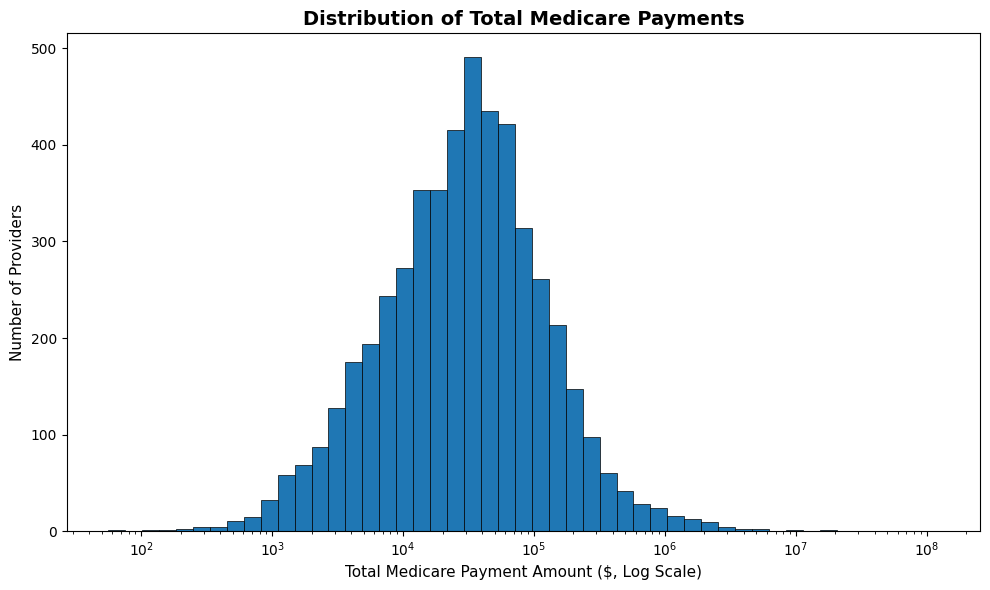

In [111]:
plt.figure(figsize=(10, 6))

plt.hist(
    df_clean["Tot_Mdcr_Pymt_Amt"],
    bins=log_bins,
    edgecolor="black",
    linewidth=0.5
)

plt.xscale("log")

plt.title(
    "Distribution of Total Medicare Payments",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel(
    "Total Medicare Payment Amount ($, Log Scale)",
    fontsize=11
)

plt.ylabel(
    "Number of Providers",
    fontsize=11
)

plt.tight_layout()

plt.show()

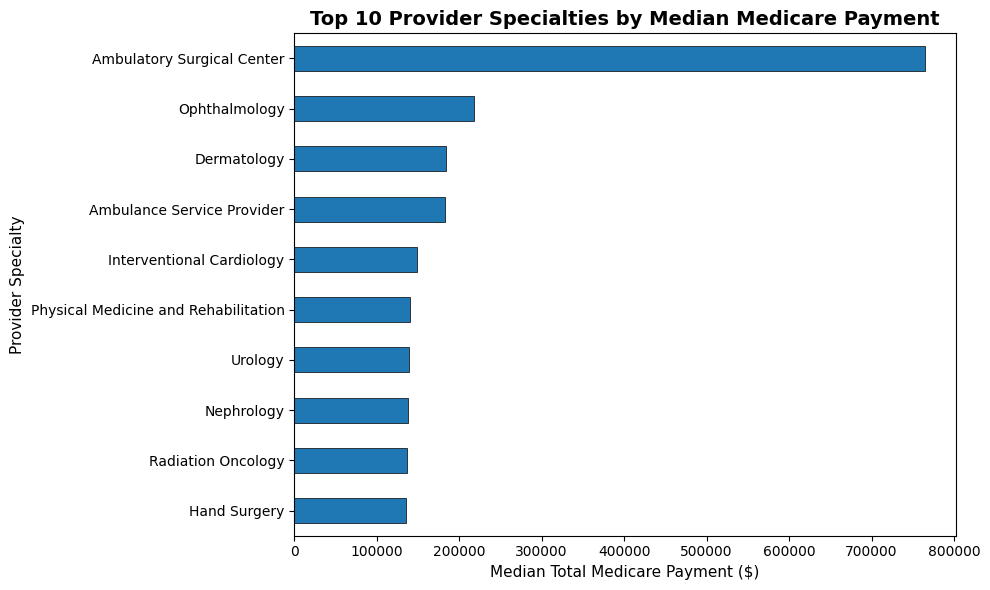

In [112]:
plt.figure(figsize=(10, 6))

specialty_stats_filtered[
    "Median_Medicare_Payment"
].sort_values().plot(
    kind="barh",
    edgecolor="black",
    linewidth=0.5
)

plt.title(
    "Top 10 Provider Specialties by Median Medicare Payment",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel(
    "Median Total Medicare Payment ($)",
    fontsize=11
)

plt.ylabel(
    "Provider Specialty",
    fontsize=11
)

plt.tight_layout()

plt.show()

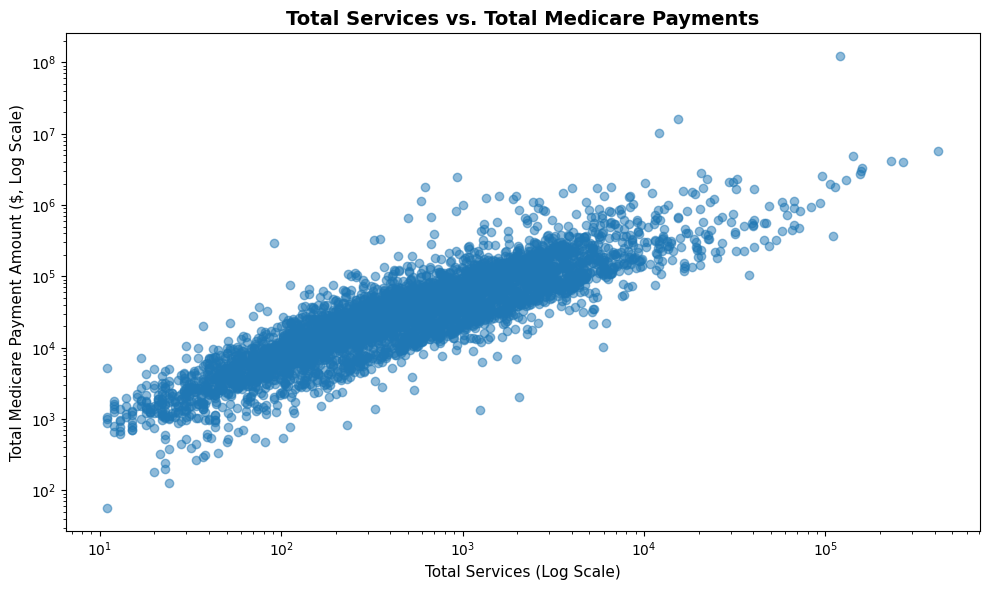

In [113]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df_clean["Tot_Srvcs"],
    df_clean["Tot_Mdcr_Pymt_Amt"],
    alpha=0.5
)

plt.xscale("log")
plt.yscale("log")

plt.title(
    "Total Services vs. Total Medicare Payments",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel(
    "Total Services (Log Scale)",
    fontsize=11
)

plt.ylabel(
    "Total Medicare Payment Amount ($, Log Scale)",
    fontsize=11
)

plt.tight_layout()

plt.show()

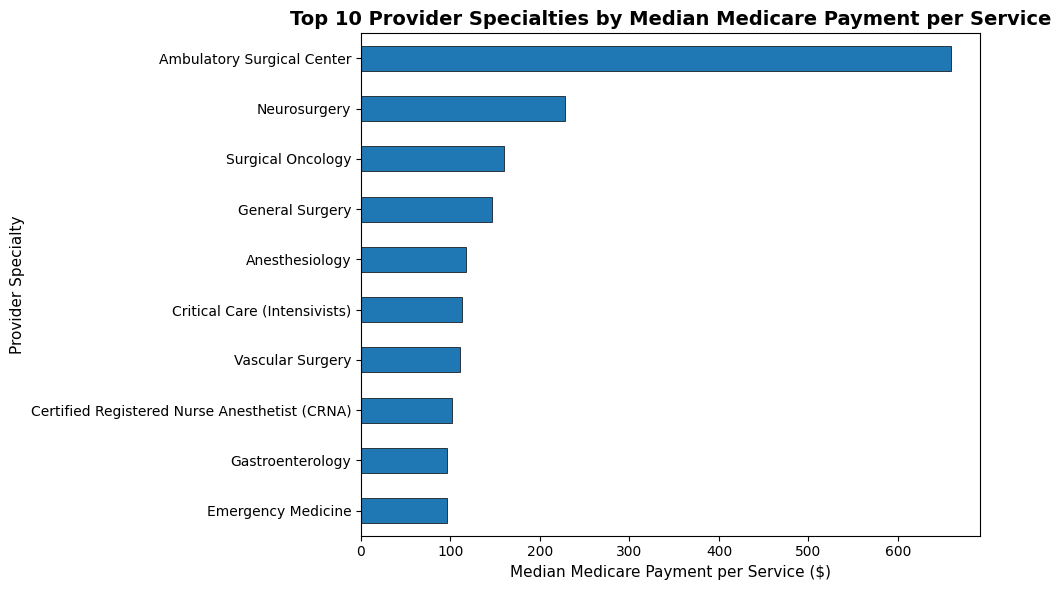

In [114]:
plt.figure(figsize=(10, 6))

top_payment_per_service[
    "Median_Payment_Per_Service"
].sort_values().plot(
    kind="barh",
    edgecolor="black",
    linewidth=0.5
)

plt.title(
    "Top 10 Provider Specialties by Median Medicare Payment per Service",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel(
    "Median Medicare Payment per Service ($)",
    fontsize=11
)

plt.ylabel(
    "Provider Specialty",
    fontsize=11
)

plt.tight_layout()

plt.show()